# Postprocess Experiment 2: CI width vs n

Loads results from `results/<experiment_id>/summary.csv`, checks status, computes coverage with an exact binomial CI, filters specs whose upper CI bound is at least 0.95, and plots CI width vs sample size (by method).


In [1]:
import os
from pathlib import Path

cwd = Path.cwd()
if cwd.name == "notebooks":
    os.chdir(cwd.parent)


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binomtest


def coverage_stats(df, lo_key, hi_key, true_key="ate_true", conf=0.95):
    sub = df[[lo_key, hi_key, true_key]].copy().dropna()
    total = len(sub)
    if total == 0:
        return pd.Series({
            "covered": 0,
            "total": 0,
            "coverage": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
        })
    covered = ((sub[lo_key] <= sub[true_key]) & (sub[true_key] <= sub[hi_key])).sum()
    p = covered / total
    ci = binomtest(int(covered), int(total)).proportion_ci(confidence_level=conf, method="exact")
    return pd.Series({
        "covered": int(covered),
        "total": int(total),
        "coverage": float(p),
        "ci_low": float(ci.low),
        "ci_high": float(ci.high),
    })


In [3]:
experiment_id = "exp2_backdoor_ate_attempt_1"
results_root = "results"

# Choose which CI to evaluate and plot.
ci_mode = "vi"  # "vi" or "analytic"
target_coverage = 0.95
dgp_filter = "dgp_1"  # set to None to include all dgps

summary_path = os.path.join(results_root, experiment_id, "summary.csv")
df = pd.read_csv(summary_path, encoding="utf-8-sig")

ci_lo_key = f"ci95_lo_{ci_mode}"
ci_hi_key = f"ci95_hi_{ci_mode}"
ci_len_key = f"ci95_len_{ci_mode}"

num_cols = ["n", "rep", "ate_true", ci_lo_key, ci_hi_key, ci_len_key]
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

status_counts = df["status"].value_counts(dropna=False)
status_counts


status
ok    3000
Name: count, dtype: int64

In [4]:
bad = df[df["status"] != "ok"]
if not bad.empty:
    bad[["run_id", "method", "dgp", "n", "rep", "status", "error_message"]].head(10)
else:
    print("All runs have status=ok")

df_base = df.copy()
if dgp_filter is not None:
    df_base = df_base[df_base["dgp"] == dgp_filter]

group_cols = ["method", "dgp", "n"]
coverage = (
    df_base.groupby(group_cols, dropna=False)
    .apply(coverage_stats, lo_key=ci_lo_key, hi_key=ci_hi_key, true_key="ate_true", conf=0.95)
    .reset_index()
)
coverage["mask"] = coverage["ci_high"] >= target_coverage
coverage.sort_values(group_cols).head(10)


All runs have status=ok


C:\Users\javurek\AppData\Local\Temp\ipykernel_5816\144533759.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(coverage_stats, lo_key=ci_lo_key, hi_key=ci_hi_key, true_key="ate_true", conf=0.95)


,method,dgp,n,covered,total,coverage,ci_low,ci_high,mask
0,aipw,dgp_1,100,43.0,50.0,0.86,0.732604,0.941808,False
1,aipw,dgp_1,200,50.0,50.0,1.00,0.928878,1.000000,True
2,aipw,dgp_1,300,50.0,50.0,1.00,0.928878,1.000000,True
3,aipw,dgp_1,400,48.0,50.0,0.96,0.862862,0.995119,True
4,aipw,dgp_1,500,49.0,50.0,0.98,0.893530,0.999494,True
5,aipw,dgp_1,600,43.0,50.0,0.86,0.732604,0.941808,False
6,aipw,dgp_1,700,46.0,50.0,0.92,0.807657,0.977772,True
7,aipw,dgp_1,800,48.0,50.0,0.96,0.862862,0.995119,True
8,aipw,dgp_1,900,47.0,50.0,0.94,0.834518,0.987451,True
9,aipw,dgp_1,1000,47.0,50.0,0.94,0.834518,0.987451,True


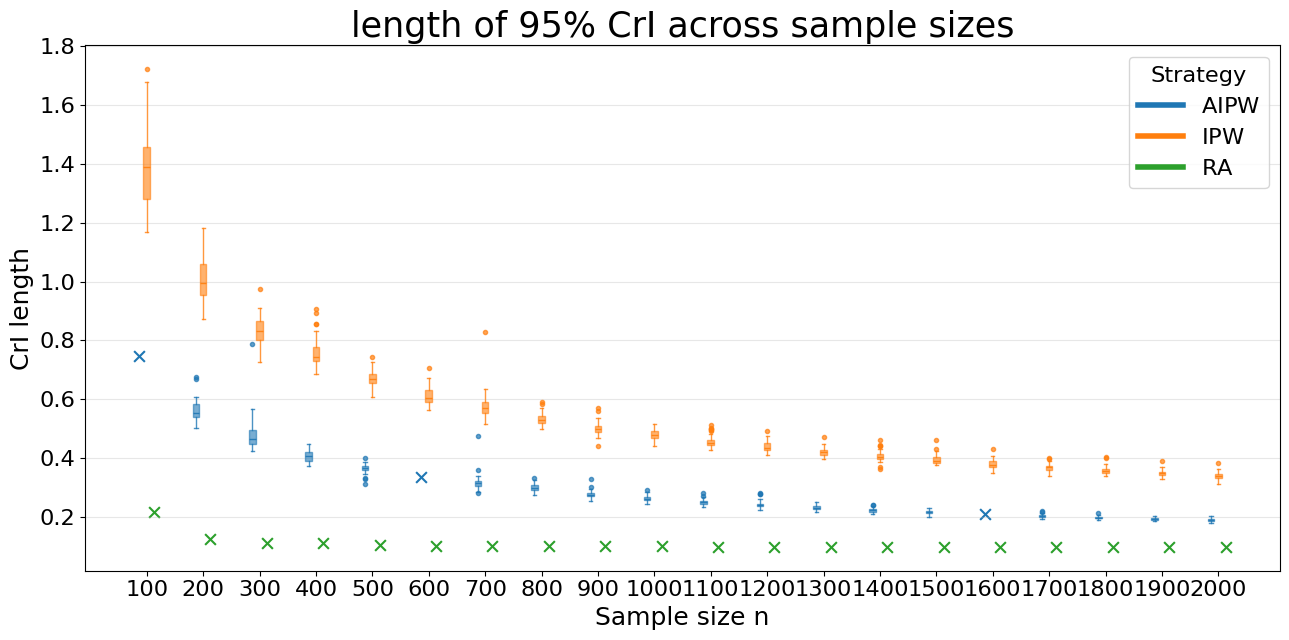

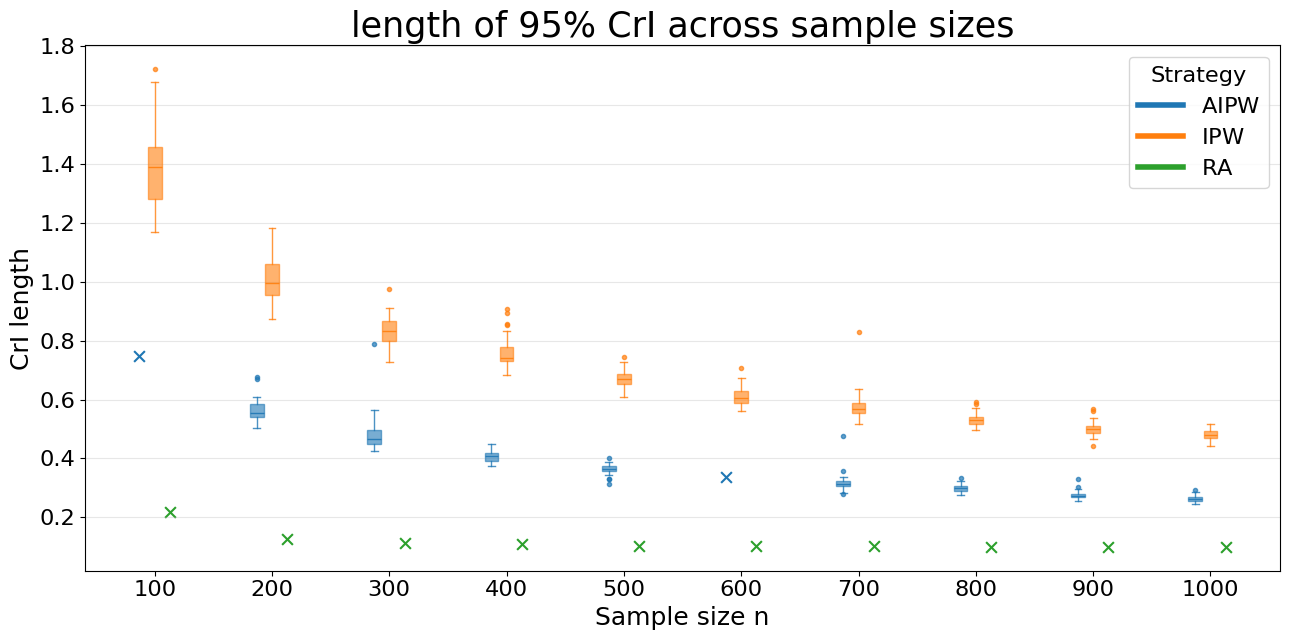

In [5]:
plot_df = df_base.merge(coverage[group_cols + ["mask"]], on=group_cols, how="left")
plot_df = plot_df.dropna(subset=[ci_len_key])

font_size = 12
font_scale = 1.5
alpha_scale = 1.0

def plot_ci_by_n(data, n_max=None, save_path=None):
    if n_max is not None:
        data = data[data["n"] <= n_max].copy()

    if data.empty:
        print("No rows remain after masking; check coverage mask or data.")
        return

    base_font = font_size * font_scale
    title_font = base_font * 1.4
    label_font = base_font * 1.0
    tick_font = base_font * 0.9
    legend_font = base_font * 0.9

    methods = sorted(data["method"].dropna().unique())
    n_order = sorted(data["n"].dropna().unique())
    palette = sns.color_palette("tab10", n_colors=len(methods))

    fig, ax = plt.subplots(figsize=(13, 6.5))
    group_gap = 1.8
    base_positions = np.arange(len(n_order)) * group_gap
    box_width = min(0.25, 0.7 / max(len(methods), 1))

    for i, method in enumerate(methods):
        color = palette[i]
        sub = data[data["method"] == method]
        positions = base_positions + (i - (len(methods) - 1) / 2) * box_width

        series_masked = [
            sub.loc[(sub["n"] == n) & (sub["mask"] == True), ci_len_key].dropna().values
            for n in n_order
        ]
        medians_masked_out = [
            sub.loc[(sub["n"] == n) & (sub["mask"] == False), ci_len_key].median()
            for n in n_order
        ]

        ax.boxplot(
            series_masked,
            positions=positions,
            widths=box_width * 0.9,
            patch_artist=True,
            manage_ticks=False,
            boxprops=dict(facecolor=color, edgecolor=color, alpha=alpha_scale * 0.6),
            whiskerprops=dict(color=color, alpha=alpha_scale * 0.8),
            capprops=dict(color=color, alpha=alpha_scale * 0.8),
            medianprops=dict(color=color, alpha=alpha_scale * 0.9),
            flierprops=dict(
                marker="o",
                markersize=3,
                markerfacecolor=color,
                markeredgecolor=color,
                alpha=alpha_scale * 0.7,
            ),
        )

        for pos, med_val in zip(positions, medians_masked_out):
            if np.isnan(med_val):
                continue
            ax.scatter(pos, med_val, marker="x", s=60, color=color, alpha=alpha_scale)

    ax.set_xticks(base_positions)
    ax.set_xticklabels([str(n) for n in n_order], fontsize=tick_font)
    ax.tick_params(axis="y", labelsize=tick_font)
    ax.set_xlabel("Sample size n", fontsize=label_font)
    # ax.set_ylabel(f"CrI length ({ci_mode})", fontsize=label_font)
    ax.set_ylabel("CrI length", fontsize=label_font)


    # title = f"CI length vs n (mask: upper CI >= {target_coverage:.2f})"
    title = "length of 95% CrI across sample sizes"
    # if dgp_filter is not None:
    #     title += f" | {dgp_filter}"
    # if n_max is not None:
    #     title += f" | n<= {int(n_max)}"
    ax.set_title(title, fontsize=title_font)
    ax.grid(axis="y", alpha=alpha_scale * 0.3)

    labels = [f"$\\mathrm{{{method.upper()}}}$" for method in methods]
    handles = [
        plt.Line2D([0], [0], color=palette[i], lw=4, alpha=alpha_scale, label=labels[i])
        for i, _ in enumerate(methods)
    ]
    ax.legend(handles=handles, title="Strategy", loc="upper right", fontsize=legend_font, title_fontsize=legend_font)
    fig.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=300)

plots_dir = os.path.join("outputs", experiment_id, "plots")
plot_ci_by_n(plot_df, save_path=os.path.join(plots_dir, f"ci_length_convergence_{ci_mode}.pdf"))
plot_ci_by_n(plot_df, n_max=1000, save_path=os.path.join(plots_dir, f"ci_length_convergence_{ci_mode}_n1000.pdf"))
